# Conditional Randomization Test (CRT) Calibration

Mirrors `Slurm_version/CRT/CRT.py` for interactive use.

CRT tests the differential effect of each gene target on each program, with optional skew-normal calibration. NTC (non-targeting) guides are randomly grouped into ensembles and used as the calibration null.

## Output structure

```
{out_dir}/{run_name}/Evaluation/{K}_{thresh}/
├── {K}_CRT_{covar_tag}_{condition}.txt    # target × program p-values + log2FC + adj_pval (per condition)
└── {K}_CRT_{covar_tag}_{condition}.png    # QQ plot: grouped NTC controls (raw vs skew) vs CRT null
```

`{covar_tag}` joins the `covariates` and `log_covariates` lists with `_`, prefixing log-transformed ones with `log_` (matching `.py`'s `_covariate_tag`). When no covariates are set, the tag is `no_covariates`.

## Assumptions about the input `.h5mu`

The `.h5mu` produced by Stage 1 inference already contains, inside the `prog_key` (`"cNMF"`) modality:
- `obsm["guide_assignment"]` (cells × guides)
- `uns["guide_names"]` (list of guide names matching guide_assignment columns)
- `uns["guide_targets"]` (target gene per guide)

So there is no separate `mdata_guide` file — the notebook reads exactly the same path that `.py` does.


In [2]:
import os
import sys
import yaml

import numpy as np
import pandas as pd
import muon as mu
import scanpy as sc
import matplotlib.pyplot as plt

# Point at B_Calibration/src so the CRT package (src/CRT/) is importable.
sys.path.append('/oak/stanford/groups/engreitz/Users/ymo/Tools/PerturbNMF/src/Stage2_Evaluation/B_Calibration/src')

from CRT import (
    prepare_crt_inputs,
    build_ntc_group_inputs,
    compute_guide_set_null_pvals,
    crt_pvals_for_ntc_groups_ensemble,
    crt_pvals_for_ntc_groups_ensemble_skew,
    make_ntc_groups_ensemble,
    run_all_genes_union_crt,
    qq_plot_real_vs_null,
)


## Step 1. Set Up

In [3]:
# ── IO ──
out_dir = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result"
run_name = "030526_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50"

# K and density thresholds to test
k = 50
sel_thresh = 0.2

# ── MuData keys ──
categorical_key = "batch"   # obs column with cell condition/sample labels

# ── Covariates (passed straight into reformat_data_for_CRT) ──
covariates = ["biological_sample"]
log_covariates = ["guide_umi_counts", "n_genes_by_counts", "total_counts", "pct_counts_mt"]

# ── Calibration parameters ──
number_guide = 8                           # NTC group size
number_permutations = 100                 # CRT B
guide_annotation_key = ["non-targeting"]   # NTC target group name(s) in mdata['cNMF'].uns['guide_targets']
FDR_method = "BH"                          # "BH" or "StoreyQ"


In [4]:
thresh_tag = str(sel_thresh).replace(".", "_")
output_folder = f"{out_dir}/{run_name}/Evaluation_Test/{k}_{thresh_tag}"
os.makedirs(output_folder, exist_ok=True)

# Load mdata — matches .py path (Inference/adata)
mdata = mu.read(
    f"{out_dir}/{run_name}/Inference/adata/cNMF_{k}_{thresh_tag}.h5mu"
)


In [5]:
adata = mdata["cNMF"].copy()
adata.obsm["cnmf_usage"] = np.asarray(adata.X)  # ensure dense float

# Guide assignment already lives in the cNMF modality of the input mdata
adata.obsm["guide_assignment"] = adata.obsm["guide_assignment"].copy()

# Program names
adata.uns["program_names"] = list(adata.var_names)

# Guide names must match columns of guide_assignment
guide_names = list(adata.uns["guide_names"])
adata.uns["guide_names"] = guide_names

guide2gene = dict(zip(guide_names, adata.uns["guide_targets"]))
adata.uns["guide2gene"] = guide2gene

# Covariates
covar_dict = {}
if covariates:
    for key in covariates:
        covar_dict[key] = adata.obs[key]
if log_covariates:
    for key in log_covariates:
        covar_dict[f"log_{key}"] = np.log1p(adata.obs[key])

adata.obsm["covar"] = pd.DataFrame(covar_dict, index=adata.obs_names)

In [6]:
adata.obsm['covar']

,biological_sample,log_guide_umi_counts,log_n_genes_by_counts,log_total_counts,log_pct_counts_mt
barcode,,,,,
CCTAATCCAACAACCATCTATTAC_2,d0_rep1,5.278115,7.625595,8.286583,2.754229
GGTGCGAACCTCCTGAATCCGCGA_2,d0_rep2,5.176150,7.711101,8.245234,2.450568
AACTCACCATCATTCCCTGTCCCG_1,d0_rep2,5.214936,7.412764,8.143888,2.390930
TTCACGCACACTTCGAATTCATGG_2,d0_rep2,1.386294,6.535241,6.692704,1.007246
GTCTGTCAGAGCTGAACCGTTCTA_3,d0_rep2,3.850148,7.872455,8.587198,2.571545
...,...,...,...,...,...
AATCCGTCTCTTCACAGTTACGTA_1,d3_rep2,2.833213,6.769642,7.457994,2.334170
ATCATTCCCGACACACTCACTTTA_2,d3_rep2,3.526361,6.410175,6.817212,2.971535
AACAACCAACACAGAAGACCTTTC_1,d3_rep1,5.521461,7.649216,8.405500,2.732527


In [7]:

# Floor program-usage matrix to avoid divide-by-zero rows
U = adata.obsm["cnmf_usage"].copy()
U = np.maximum(U, 1e-8)
U /= U.sum(axis=1, keepdims=True)
adata.obsm["cnmf_usage"] = U

In [8]:
parts = list(covariates or []) + [f"log_{c}" for c in (log_covariates or [])]
covar_tag = "_".join(parts) if parts else "no_covariates"
covar_tag

'biological_sample_log_guide_umi_counts_log_n_genes_by_counts_log_total_counts_log_pct_counts_mt'

In [9]:
for condition in adata.obs[categorical_key].unique():
        print(f"  Condition: {condition}")
        adata_con = adata[adata.obs[categorical_key] == condition].copy()

  Condition: D0
  Condition: D1
  Condition: D2
  Condition: D3


In [10]:
adata_con

AnnData object with n_obs × n_vars = 44102 × 50
    obs: 'guides_per_cell', 'guide_umi_counts', 'pct_counts_ribo', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pool', 'sample_id', 'round1', 'well', 'biological_sample', 'plate', 'bci', 'stype', 'day', 'cell_pool', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'S_score', 'G2M_score', 'phase', 'outlier', 'size_factors', 'leiden_res_0.1', 'leiden_res_0.2', 'leiden_res_0.3', 'leiden_res_0.4', 'leiden_res_0.5', 'leiden_res_0.6', 'leiden_res_0.7', 'leiden_res_0.8', 'leiden_res_0.9', 'leiden_res_1.0', 'batch'
    uns: 'guide_names', 'guide_targets', 'var_names', 'program_names', 'guide2gene'
    obsm: 'X_pca', 'X_umap', 'guide_assignment', 'cnmf_usage', 'covar'
    varm: 'loadings'

In [11]:
inputs = prepare_crt_inputs(
            adata=adata_con,
            usage_key="cnmf_usage",
            covar_key="covar",
            guide_assignment_key="guide_assignment",
            guide2gene_key="guide2gene",
        )

In [12]:
out = run_all_genes_union_crt(
            inputs=inputs,
            B=number_permutations,
            n_jobs=-1,
            calibrate_skew_normal=True,
            return_raw_pvals=True,
            return_skew_normal=True,
        )

In [13]:
ntc_labels = guide_annotation_key
ntc_guides, guide_freq, guide_to_bin, real_sigs = build_ntc_group_inputs(
    inputs=inputs,
    ntc_label=ntc_labels,
    group_size=number_guide,
    n_bins=15,
)

ntc_groups_ens = make_ntc_groups_ensemble(
    ntc_guides=ntc_guides,
    ntc_freq=guide_freq,
    real_gene_bin_sigs=real_sigs,
    guide_to_bin=guide_to_bin,
    n_ensemble=10,
    seed0=7,
    group_size=number_guide,
    max_groups=None,
)

ntc_group_pvals_ens = crt_pvals_for_ntc_groups_ensemble(
    inputs=inputs,
    ntc_groups_ens=ntc_groups_ens,
    B=number_permutations,
    seed0=23,
)


In [14]:

# CRT-null matched to NTC group units
guide_to_col = {g: i for i, g in enumerate(inputs.guide_names)}
null_pvals = np.concatenate(
    [
        compute_guide_set_null_pvals(
            guide_idx=[guide_to_col[g] for g in guides],
            inputs=inputs,
            B=number_permutations,
        ).ravel()
        for groups in ntc_groups_ens
        for guides in groups.values()
    ]
)

<Axes: title={'center': 'QQ plot: grouped NTC controls (raw vs skew) vs CRT null for D3'}, xlabel='Expected -log10(p)', ylabel='Observed -log10(p)'>

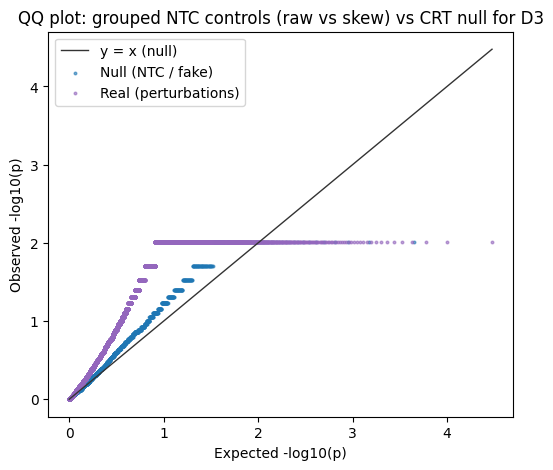

In [16]:
qq_plot_real_vs_null(
    real_pvals=out["pvals_raw_df"],
    null_pvals=ntc_group_pvals_ens,
    title=f"QQ plot: grouped NTC controls (raw vs skew) vs CRT null for {condition}",
)